In [7]:
import pandas as pd
df = pd.read_csv("accepted_loans_300k.csv", low_memory=False)


In [8]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,85217744,NaN,12000.0,12000.0,12000.0,36 months,11.49,395.66,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,5774545,NaN,3000.0,3000.0,3000.0,36 months,15.22,104.32,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,98033512,NaN,11750.0,11750.0,11750.0,36 months,11.44,387.14,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,6728064,NaN,6950.0,6950.0,6950.0,36 months,15.88,243.93,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,1515602,NaN,23000.0,23000.0,23000.0,36 months,7.62,716.72,A,A3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df.shape

(300000, 151)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Columns: 151 entries, id to settlement_term
dtypes: float64(113), int64(1), object(37)
memory usage: 345.6+ MB


In [25]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,3.000000e+05,0.0,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,3.000000e+05,299929.000000,300000.000000,...,1204.0,1204.000000,1204.0,1204.000000,801.000000,1204.000000,1204.000000,7280.000000,7280.000000,7280.000000
mean,5.303157e+07,NaN,14445.307500,14435.580583,14411.322878,13.199415,438.393875,7.603415e+04,18.271254,0.317210,...,3.0,146.326412,3.0,13.767442,417.630899,10820.112575,184.754493,4980.387547,47.582067,12.753709
std,3.731043e+07,NaN,8660.878709,8656.603799,8659.774819,4.730179,259.398049,6.808624e+04,11.172104,0.882888,...,0.0,131.900814,0.0,9.968649,376.128657,7434.513008,199.483394,3673.020391,7.146969,8.279642
min,5.670500e+04,NaN,500.000000,500.000000,0.000000,5.310000,16.080000,0.000000e+00,0.000000,0.000000,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,121.910000,0.550000,0.000000
25%,1.713025e+07,NaN,8000.000000,8000.000000,8000.000000,9.710000,250.150000,4.560000e+04,11.800000,0.000000,...,3.0,53.467500,3.0,0.000000,141.330000,5036.047500,37.852500,2200.000000,45.000000,6.000000
50%,5.452329e+07,NaN,12000.000000,12000.000000,12000.000000,12.740000,376.120000,6.500000e+04,17.630000,0.000000,...,3.0,109.475000,3.0,15.000000,318.060000,9060.600000,117.315000,4120.580000,45.000000,12.000000
75%,7.603234e+07,NaN,20000.000000,20000.000000,20000.000000,15.990000,580.220000,9.000000e+04,24.040000,0.000000,...,3.0,196.060000,3.0,23.000000,563.640000,14790.340000,269.007500,6849.467500,50.000000,18.000000
max,1.456237e+08,NaN,40000.000000,40000.000000,40000.000000,30.990000,1719.830000,9.300000e+06,999.000000,30.000000,...,3.0,943.940000,3.0,37.000000,2267.280000,36890.900000,1275.360000,33601.000000,184.360000,65.000000


In [11]:
df["risk"] = df["loan_status"].apply(
    lambda x: 1 if x in [
        "Charged Off",
        "Default",
        "Late (31-120 days)",
        "Late (16-30 days)"
    ] else 0
)

In [13]:
if df["term"].dtype == "object":
    df["term"] = df["term"].str.extract(r"(\d+)").astype(int)

In [15]:
cols = [
    "loan_amnt", "term", "annual_inc", "dti",
    "fico_range_low", "home_ownership",
    "emp_length", "grade", "purpose", "risk"
]
df = df[cols]


In [19]:
df.dtypes

loan_amnt         float64
term                int32
annual_inc        float64
dti               float64
fico_range_low    float64
home_ownership     object
emp_length         object
grade              object
purpose            object
risk                int64
dtype: object

In [21]:
df.shape

(300000, 10)

In [24]:
df.isnull().sum()


loan_amnt             0
term                  0
annual_inc            0
dti                  71
fico_range_low        0
home_ownership        0
emp_length        17216
grade                 0
purpose               0
risk                  0
dtype: int64

In [27]:
df.dropna(inplace=True)

In [30]:
df.isnull().sum()

loan_amnt         0
term              0
annual_inc        0
dti               0
fico_range_low    0
home_ownership    0
emp_length        0
grade             0
purpose           0
risk              0
dtype: int64

In [33]:
df.shape

(282781, 10)

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

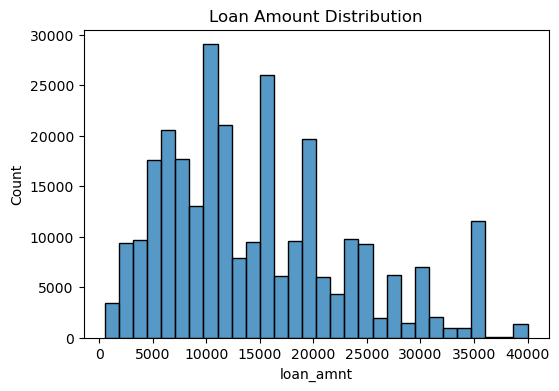

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amnt'], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

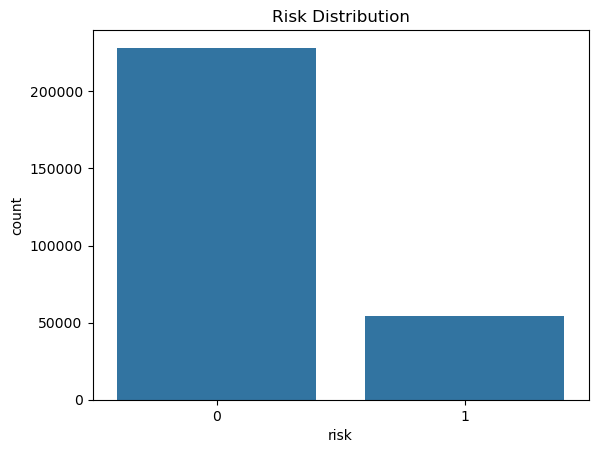

In [39]:
sns.countplot(x="risk", data=df)
plt.title("Risk Distribution")
plt.show()


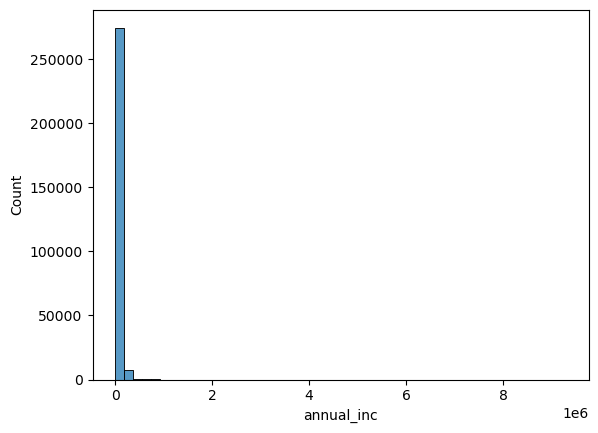

In [41]:
sns.histplot(df["annual_inc"], bins=50)
plt.show()


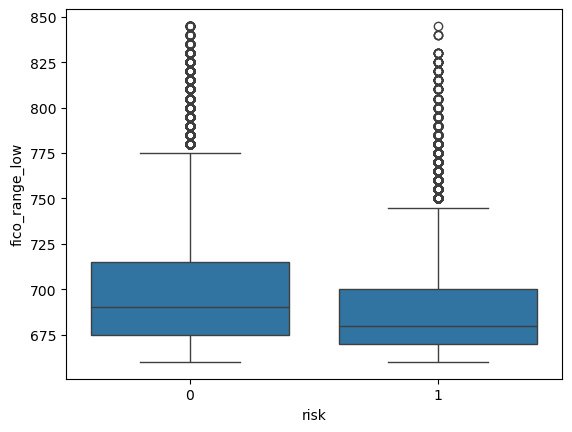

In [43]:
sns.boxplot(x="risk", y="fico_range_low", data=df)
plt.show()

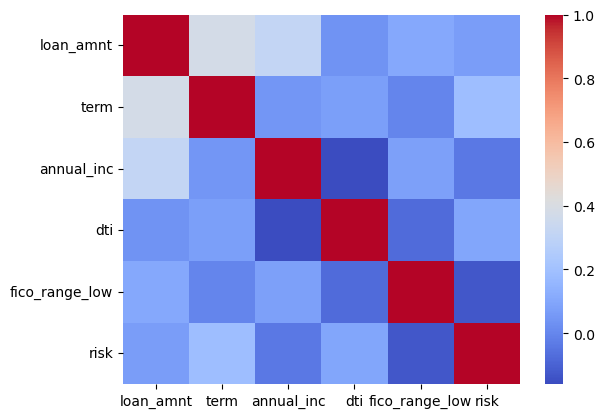

In [45]:
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm")
plt.show()

In [47]:
X = df.drop("risk", axis=1)
y = df["risk"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [53]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [55]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [57]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [59]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['loan_amnt', 'annual_inc', 'dti', 'fico_range_low'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['home_ownership', 'emp_length', 'grade', 'purpose'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['loan_amnt', 'annual_inc', 'dti', 'fico_range_low'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['home_ownership', 'emp_length', 'grade', 'purpose'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [63]:
from sklearn.metrics import classification_report, roc_auc_score

In [65]:
def evaluate(model):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    print(classification_report(y_test, preds))
    print("ROC AUC:", roc_auc_score(y_test, proba))


In [67]:
evaluate(lr_pipeline)
evaluate(rf_pipeline)

              precision    recall  f1-score   support

           0       0.81      1.00      0.89     45657
           1       0.56      0.03      0.05     10900

    accuracy                           0.81     56557
   macro avg       0.69      0.51      0.47     56557
weighted avg       0.76      0.81      0.73     56557

ROC AUC: 0.7007173985600246
              precision    recall  f1-score   support

           0       0.81      1.00      0.89     45657
           1       0.77      0.00      0.00     10900

    accuracy                           0.81     56557
   macro avg       0.79      0.50      0.45     56557
weighted avg       0.80      0.81      0.72     56557

ROC AUC: 0.7027621185332272


In [69]:
import joblib
joblib.dump(rf_pipeline, "risk_pipeline.pkl")


['risk_pipeline.pkl']

In [71]:
# Select only the 5 input features
features = ['loan_amnt', 'term', 'annual_inc', 'dti', 'fico_range_low']
X = df[features]
y = df['risk']

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use class_weight='balanced' to avoid predicting mostly LOW RISK
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, class_weight='balanced'))
])

pipeline.fit(X, y)

# Save the pipeline
import joblib
joblib.dump(pipeline, "risk_pipeline_5inputs.joblib")


['risk_pipeline_5inputs.joblib']



## Project Title
**Industry-Level Financial Risk Profiling System Using Machine Learning**

---

## Objective
Develop an end-to-end system for assessing loan applicant risk using financial data. The system predicts default probability, calculates a risk score, categorizes risk, and recommends suitable financial products. The solution is deployed as a professional Streamlit web app with minimal, high-impact inputs.

---

## Dataset Used
- **Source:** Lending Club “Accepted Loans” dataset  
- **Rows:** 300,000 (reduced from full dataset for efficiency)
- **Columns:** 151  
- **Key Features:**
  1. Loan Amount (`loan_amnt`)  
  2. Loan Term (`term`)  
  3. Annual Income (`annual_inc`)  
  4. Debt-to-Income Ratio (`dti`)  
  5. FICO Score (`fico_range_low`)  
- **Target Variable:** `risk` (0 = Low Risk / Fully Paid, 1 = High Risk / Defaulted)

---

# Sprint 0: Exploratory Data Analysis (EDA)

### Steps:
1. **Understanding the Data:** Examined attributes, types, missing values.  
2. **Data Cleaning:** Removed unnecessary columns, converted `term` to numeric, ensured numeric columns are proper type.  
3. **Data Types:**  
   - Discrete: `term`  
   - Continuous: `loan_amnt`, `annual_inc`, `dti`, `fico_range_low`  
4. **Analysis Questions:**  
   - How do loan amount, DTI, FICO score, and loan term affect default probability?  
   - Can applicants be classified into Low/Medium/High risk?  
5. **Visualization:**  
   - Histograms for numeric features  
   - Correlation heatmap  
   - Boxplots to detect trends and outliers  

**Outcome:** Identified 5 key predictive features: loan amount, term, annual income, DTI, and FICO score.

---

# Sprint 1: Preprocessing & Feature Engineering

### Steps:
1. Selected 5 high-impact features.  
2. Preprocessed data:
   - Filled missing values
   - Scaled numeric features using `StandardScaler`  
   - Converted categorical features if any (not needed for 5 features)  
3. Split dataset into training and testing sets.  
4. Addressed class imbalance with `class_weight='balanced'` in Random Forest.
5. **Feature Engineering:**  
   - Converted `term` from string (e.g., "36 months") to numeric (36).  
   - Derived **FICO Score** directly from the lower range (`fico_range_low`).  
   - Normalized features using **StandardScaler** within a pipeline.  
   - Optional derived features for reasoning:
     - `high_loan_flag = loan_amnt > 200000`  
     - `high_dti_flag = dti > 25`  
     - `low_fico_flag = fico_range_low < 660`  
   - These flags help in generating **dynamic reasoning and recommendations** in the app.

**Outcome:** Preprocessed dataset ready for modeling.

---

# Sprint 2: Model Development

### Steps:
1. **Model Selection:** Random Forest Classifier for high accuracy and interpretability.  
2. **Pipeline Creation:** `Pipeline` including `StandardScaler` + Random Forest.  
3. **Training:** 

pipeline.fit(X_train, y_train)

**Evaluation Metrics:** Accuracy, ROC-AUC, Precision, Recall, F1-score.

### Thresholds for Risk Categories:

prob < 0.3 → LOW RISK

0.3 ≤ prob < 0.6 → MEDIUM RISK

prob ≥ 0.6 → HIGH RISK



# Sprint 3: Deployment (Streamlit App)
### Steps:

Interface Design: Minimal professional input with only 5 fields.

**Predictive Outputs:**

Risk Probability (% chance of default)

Risk Score (0–100)

Risk Category (Low / Medium / High)

Recommended Product / Investment

Dynamic reasoning (e.g., “Large loan amount + High DTI → higher default risk”)

Pipeline Integration: Loaded pre-trained pipeline using joblib.

Advanced Features: Lightweight, handles class imbalance, professional interface.

Outcome: Fully functional Financial Risk Profiling App ready for real-world usage.

| Loan Amount | Term | Annual Income | DTI | FICO | Risk Probability | Risk Score | Risk Category | Recommendation                |
| ----------: | ---: | ------------: | --: | ---: | ---------------: | ---------: | ------------- | ----------------------------- |
|      50,000 |   36 |       400,000 |  10 |  720 |              12% |   12 / 100 | LOW RISK      | Equity / Mutual Funds         |
|     200,000 |   60 |       350,000 |  25 |  680 |              45% |   45 / 100 | MEDIUM RISK   | Balanced Funds / Secured Loan |
|     350,000 |   60 |       250,000 |  35 |  600 |              78% |   78 / 100 | HIGH RISK     | Fixed Deposit / Bonds         |


# Project Achievements

+ Professional end-to-end ML project: EDA, preprocessing, modeling, deployment

+ User-friendly interface with minimal inputs

+ Industry relevance: Risk profiling for banks and financial institutions

+ Custom recommendations and reasoning provided

+ Scalable: Lightweight pipeline avoids memory issues


# Conclusion

**Input:** 5 high-impact features from customer financial data

**Output:** Risk probability, risk score, risk category, recommendation, reasoning

**Methodology:** Python → Pandas → Scikit-learn → Streamlit

**Impact:** Provides actionable insights for lending decisions; suitable for industry deployment